# 03-logistic-regression.ipynb
Train Logistic Regression bằng Scikit-Learn và From Scratch

In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [2]:

df = pd.read_csv('./data/preprocessed/enron_spam_data_preprocessed.csv')
df = df.fillna('')

df['text'] = df['Subject'].astype(str) + ' ' + df['Message'].astype(str)
df['label'] = df['Label'].map({'ham':0, 'spam':1})

X = df['text']
y = df['label']

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(24383, 5000) (6096, 5000)


## Logistic Regression - Scikit Learn

In [3]:

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))


Accuracy : 0.9837598425196851
Precision: 0.9763113367174281
Recall   : 0.9900480439258751
F1-score : 0.9831317089793832


## Logistic Regression - From Scratch

In [4]:

X_train_np = X_train.toarray()
X_test_np = X_test.toarray()

y_train_np = y_train.values.reshape(-1,1)
y_test_np = y_test.values.reshape(-1,1)

def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-500,500)))

class LogisticRegressionScratch:

    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):

        m, n = X.shape

        self.w = np.zeros((n,1))
        self.b = 0

        for epoch in range(self.epochs):

            z = np.dot(X, self.w) + self.b
            y_hat = sigmoid(z)

            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):

        z = np.dot(X, self.w) + self.b
        probs = sigmoid(z)

        return (probs >= 0.5).astype(int)

scratch_model = LogisticRegressionScratch(lr=0.1, epochs=1000)
scratch_model.fit(X_train_np, y_train_np)

y_pred_scratch = scratch_model.predict(X_test_np)

print('Accuracy :', accuracy_score(y_test_np, y_pred_scratch))
print('Precision:', precision_score(y_test_np, y_pred_scratch))
print('Recall   :', recall_score(y_test_np, y_pred_scratch))
print('F1-score :', f1_score(y_test_np, y_pred_scratch))


Accuracy : 0.9670275590551181
Precision: 0.9612376742604556
Recall   : 0.9701441317776253
F1-score : 0.965670367207515


In [5]:

results = pd.DataFrame({
    'Model':['Logistic Regression (Sklearn)','Logistic Regression (Scratch)'],
    'Accuracy':[accuracy_score(y_test, y_pred),
                accuracy_score(y_test_np, y_pred_scratch)],
    'Precision':[precision_score(y_test, y_pred),
                 precision_score(y_test_np, y_pred_scratch)],
    'Recall':[recall_score(y_test, y_pred),
              recall_score(y_test_np, y_pred_scratch)],
    'F1':[f1_score(y_test, y_pred),
          f1_score(y_test_np, y_pred_scratch)]
})

results


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Sklearn),0.983760,0.976311,0.990048,0.983132
1,Logistic Regression (Scratch),0.967028,0.961238,0.970144,0.965670


## Classification Report - Scikit Learn

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3182
           1       0.98      0.99      0.98      2914

    accuracy                           0.98      6096
   macro avg       0.98      0.98      0.98      6096
weighted avg       0.98      0.98      0.98      6096



## Confusion Matrix - Scikit Learn

In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3112   70]
 [  29 2885]]


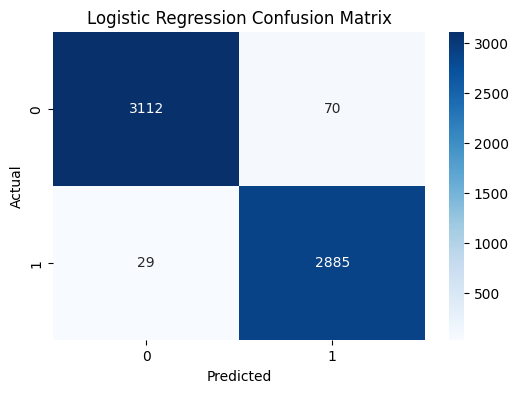

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Classification Report - Scratch

In [9]:
print(classification_report(y_test_np, y_pred_scratch))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3182
           1       0.96      0.97      0.97      2914

    accuracy                           0.97      6096
   macro avg       0.97      0.97      0.97      6096
weighted avg       0.97      0.97      0.97      6096



## Confusion Matrix - Scratch

In [10]:
cm_scratch = confusion_matrix(y_test_np, y_pred_scratch)
print(cm_scratch)

[[3068  114]
 [  87 2827]]


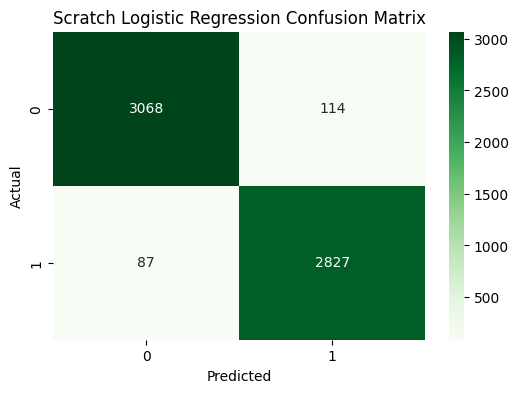

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Greens')
plt.title('Scratch Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Export Results

In [12]:
results.to_csv('logistic_regression_results.csv', index=False)
results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression (Sklearn),0.983760,0.976311,0.990048,0.983132
1,Logistic Regression (Scratch),0.967028,0.961238,0.970144,0.965670
